## _Topic Modeling based on Reviews_
***
<b>DESCRIPTION</b>

You are asked to analyze customer reviews from an e-commerce platform. More specifically, you will perform topic modeling to identify common themes in the reviews, apply POS tagging to extract grammatical information and utilize lemmatization to normalize the words for better
analysis.

<b>Problem Statement: </b>

A popular mobile phone brand, Lenovo has launched their budget smartphone in the Indian market. The client wants to understand the VOC (voice of the customer) on the product. This will be useful to not just evaluate the current product, but to also get some direction for developing the product pipeline. The client is particularly interested in the different aspects that customers care about. Product reviews by customers on a leading e-commerce site should provide a good view.

<b>Domain: Amazon reviews for a leading phone brand</b>

- Analysis to be done: POS tagging, topic modeling using LDA, and topic interpretation

<b> Content: </b>

- Dataset: ‘K8 Reviews v0.2.csv’

<b>Columns:</b>
- Sentiment: The sentiment against the review (4,5 star reviews are positive, 1,2 are negative)
- Reviews: The main text of the review

<b>Steps to perform:</b>

Discover the topics in the reviews and present it to business in a consumable format. Employ techniques in syntactic processing and topic modeling.
Perform specific cleanup, POS tagging, and restricting to relevant POS tags, then, perform topic modeling using LDA. 

<b>Tasks: </b>
- Read the .csv file using Pandas. Take a look at the top few records.
- Normalize casings for the review text and extract the text into a list for easier manipulation.
- Tokenize the reviews using NLTKs word_tokenize function.
- Perform parts-of-speech tagging on each sentence using the NLTK POS tagger.
- For the topic model, we should  want to include only nouns.
- Find out all the POS tags that correspond to nouns.
- Limit the data to only terms with these tags.
- Lemmatize. 
- Different forms of the terms need to be treated as one.
- No need to provide POS tag to lemmatizer for now.
- Remove stopwords and punctuation (if there are any). 
- Create a topic model using LDA on the cleaned up data with 12 topics.
- Print out the top terms for each topic.
- What is the coherence of the model with the c_v metric?
- Analyze the topics through the business lens.
- Determine which of the topics can be combined.
- Create topic model using LDA with what you think is the optimal number of topics
- What is the coherence of the model?
- Create a table with the topic name and the top 10 terms in each to present to the  business.



In [4]:
# write the list of necessary packages here:
!pip install pandas
!pip install nltk
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install scikit-learn
!pip install gensim
!pip install matplotlib
!pip install seaborn
!pip install wordcloud



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for numpy>=1.19.0 from https://files.pythonhosted.org/packages/b2/b5/4ac39baebf1fdb2e72585c8352c56d063b6126be9fc95bd2bb5ef5770c20/numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\salim\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\~4mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


...


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blis 1.0.1 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.2 requires numpy<2.1.0,>=2.0.0; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for numpy<2.0,>=1.18.5 from https://files.pythonhosted.org/packages/16/2e/86f24451c2d530c88daf997cb8d6ac622c1d40d19f5a031ed68a4b73a374/numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## _Import Libraries and Load the Data_

In [5]:
# import your packages here:
import numpy as np
import pandas as pd
#file and system operations
import os
import sys
#visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#consistent sized plots
from pylab import rcParams
rcParams['figure.figsize']=12,5
rcParams['axes.labelsize']=12
rcParams['ytick.labelsize']=12
rcParams['xtick.labelsize']=12
#handle unwanted warnings 
import warnings
warnings.filterwarnings(action='ignore',category=DeprecationWarning)
warnings.filterwarnings(action='ignore',category=FutureWarning)
#view all the columns
pd.options.display.max_columns = None
#basic text manipulation libraries
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import nltk
import spacy
import string
import gensim
from gensim import corpora
from wordcloud import WordCloud
from gensim.models import CoherenceModel




### _Load the Reviews Data_

In [6]:
reviews = pd.read_csv('K8 Reviews v0.2.csv',delimiter=',')
reviews.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'K8 Reviews v0.2.csv'

In [ ]:
#check the number of reviews 
len(reviews)

14675

In [ ]:
#check the basic info
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14675 entries, 0 to 14674
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  14675 non-null  int64 
 1   review     14675 non-null  object
dtypes: int64(1), object(1)
memory usage: 229.4+ KB


- _There are no null values or missing values in the dataset_

In [ ]:
#check the sentiment labels
reviews['sentiment'].value_counts()

sentiment
0    7712
1    6963
Name: count, dtype: int64

In [ ]:
#ns.countplot(reviews['sentiment'])
#plt.title('Count of the review sentiments')
#plt.show()

- _The data seems to be fairly balanced. However, the objective of this project is to do topic modeling and not sentiment classification_

## _Text Preprocessing_
_Following steps will be performed_
- Tokenization - Split the text into sentences and sentences into words. Lowercase the words and remove any punctuation_
- All stopwords will be removed_
- Eliminate the tokens except nouns, noun phrases and verbs.
- Words are lemmatized - words in third person are changed to first person and words in future and past tense are changed to present tense_

In [ ]:
# write your code here:

nltk.download('punkt')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
   
    sentences = sent_tokenize(text)
    processed_tokens = []

    for sentence in sentences:
        # Tokenize and lowercase
        tokens = word_tokenize(sentence.lower())
        
        # Remove punctuation
        tokens = [token for token in tokens if token not in string.punctuation]
        
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]
        
        doc = nlp(' '.join(tokens))
        
        filtered_tokens = [
            token.lemma_ 
            for token in doc 
            if token.pos_ in ['NOUN', 'PROPN', 'VERB']
        ]
        
        processed_tokens.extend(filtered_tokens)
    
    return processed_tokens


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\salim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Topic Modeling

Implement topic modeling using Latent Dirichlet Allocation (LDA) which is a topic modeling technique for uncovering the central topics and their distributions across a set of documents. Identify and list the top 5 topics found in the reviews along with their associated keywords.

In [ ]:
# write your code here:
processed_reviews = [preprocess_text(review) for review in reviews['review']]

dictionary = corpora.Dictionary(processed_reviews)
corpus = [dictionary.doc2bow(review) for review in processed_reviews]

# Perform LDA
lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10,
    workers=2
)

# Display topics with keywords
def display_topics(lda_model, top_n=10):
    for idx, topic in lda_model.print_topics(num_words=top_n):
        print(f"Topic {idx + 1}:")
        print(topic)
        print()

display_topics(lda_model, top_n=10)

coherence_model = CoherenceModel(
    model=lda_model, 
    texts=processed_reviews, 
    dictionary=dictionary, 
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score (c_v): {coherence_score}")



KeyboardInterrupt: 

In [ ]:
def assign_dominant_topic(lda_model, corpus):
   
    dominant_topics = []
    for idx, doc in enumerate(lda_model[corpus]):
        sorted_topics = sorted(doc, key=lambda x: x[1], reverse=True)  # Sort by topic probability
        dominant_topic, topic_prob = sorted_topics[0]  # Take the most dominant topic
        dominant_topics.append((dominant_topic, topic_prob, idx))  
    return dominant_topics

def print_one_example_per_topic(dominant_topics, reviews):
    """
    Print one example review for each topic.
    
    """
    topic_to_example = {}

    for topic, prob, idx in dominant_topics:
        if topic not in topic_to_example:  
            topic_to_example[topic] = (prob, reviews[idx])

    for topic, (prob, review) in sorted(topic_to_example.items()):
        print(f"\n--- Topic {topic + 1} ---")
        print(f"Probability: {prob:.2f}")
        print(f"Review: {review}")
        print()

# Assign dominant topics to each review
dominant_topics = assign_dominant_topic(lda_model, corpus)

print_one_example_per_topic(dominant_topics, reviews['review'])


--- Topic 1 ---
Probability: 0.57
Review: Good but need updates and improvements


--- Topic 2 ---
Probability: 0.61
Review: Worst mobile i have bought ever, Battery is draining like hell, backup is only 6 to 7 hours with internet uses, even if I put mobile idle its getting discharged.This is biggest lie from Amazon & Lenove which is not at all expected, they are making full by saying that battery is 4000MAH & booster charger is fake, it takes at least 4 to 5 hours to be fully charged.Don't know how Lenovo will survive by making full of us.Please don;t go for this else you will regret like me.


--- Topic 3 ---
Probability: 0.54
Review: Phone is awesome. But while charging, it heats up allot..Really a genuine reason to hate Lenovo k8 note


--- Topic 4 ---
Probability: 0.55
Review: when I will get my 10% cash back.... its already 15 January..


--- Topic 5 ---
Probability: 0.60
Review: headset is not available



### Reporting





The number of topics was selected by calculating coherence scores for different values.
Employed the c_v coherence type.

### Visualization

Plot word clouds for each topic displaying associated keywords

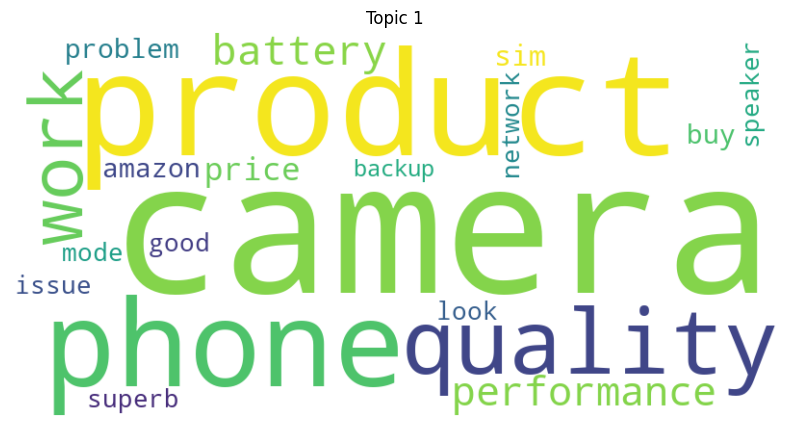

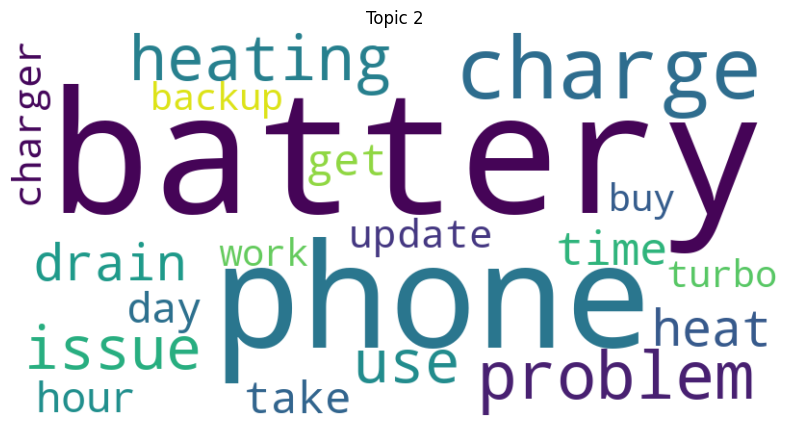

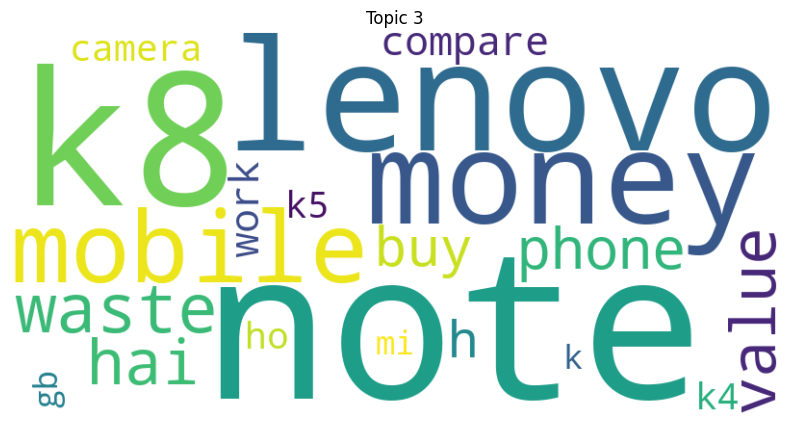

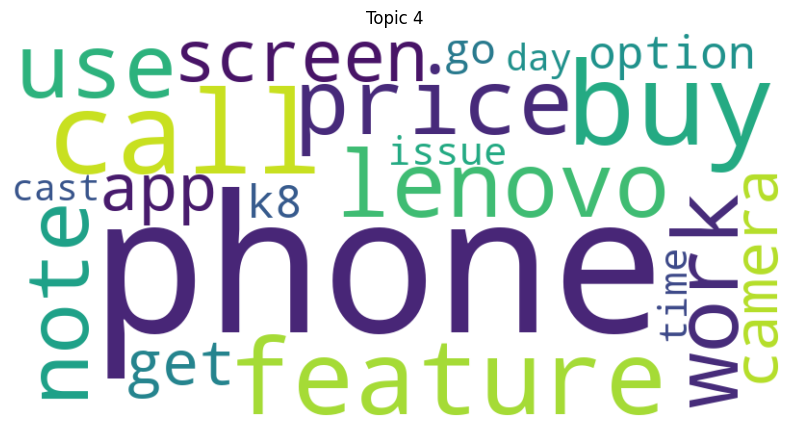

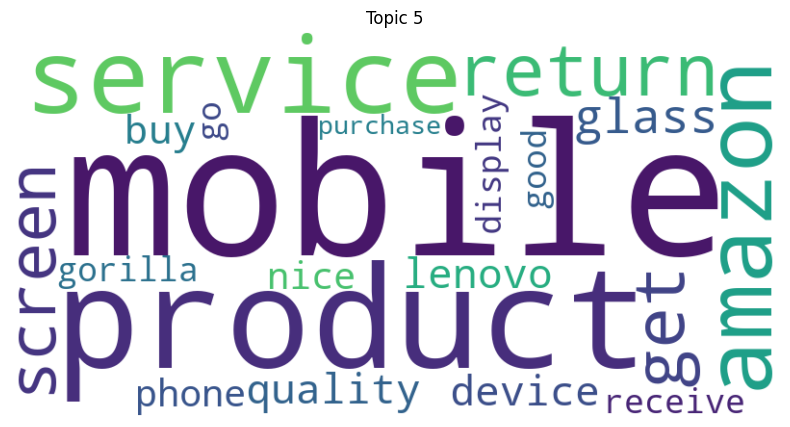

In [ ]:
# write your code here:
# Generate word clouds for topics
def generate_word_clouds(lda_model):
    for idx, topic in lda_model.print_topics(num_words=20):
        word_weights = {}
        for word_weight in topic.split('+'):
            weight, word = word_weight.strip().split('*')
            word = word.strip('"')
            word_weights[word] = float(weight)
        
        # Create WordCloud
        wordcloud = WordCloud(width=800, height=400, background_color='white')
        wordcloud.generate_from_frequencies(word_weights)
        
        # Plot WordCloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Topic {idx + 1}")
        plt.show()

generate_word_clouds(lda_model)

